In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Online-Store-Orders.csv')
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [3]:
# EDA 
# 1. Top Selling Products
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head()
print("Top 5 Products by Quantity Sold:", top_products)

Top 5 Products by Quantity Sold: Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Name: Quantity, dtype: int64


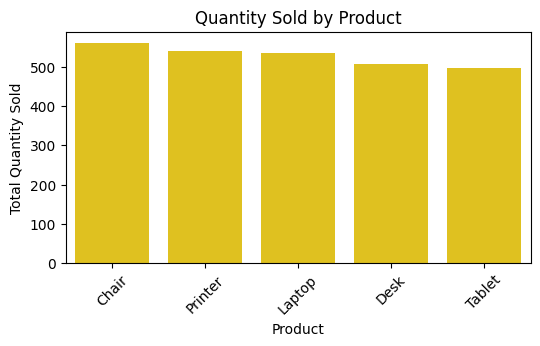

In [4]:
plt.figure(figsize=(6,3))
sns.barplot(x=top_products.index, y=top_products.values,color='gold')
plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()


In [5]:
# 2. Total Sales
total_sales = df['TotalPrice'].sum()
print("Total Sales:", total_sales)

Total Sales: 1264761.96


In [6]:
# 3. Average Order Value
average_order_value = df['TotalPrice'].mean()
print("Average Order Value: ", average_order_value)

Average Order Value:  1053.9683


In [7]:
# 4. Highest Revenue Poduct
revenue_by_Product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head()
print("Highest Revenue Product: ", revenue_by_Product)

Highest Revenue Product:  Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Name: TotalPrice, dtype: float64


In [8]:
# 5. Payment Method Distribution
payment_method_distribution = df['PaymentMethod'].unique()
print("Payment Method Distribution: ", payment_method_distribution) 

Payment Method Distribution:  ['Debit Card' 'Online' 'Credit Card' 'Gift Card' 'Cash']


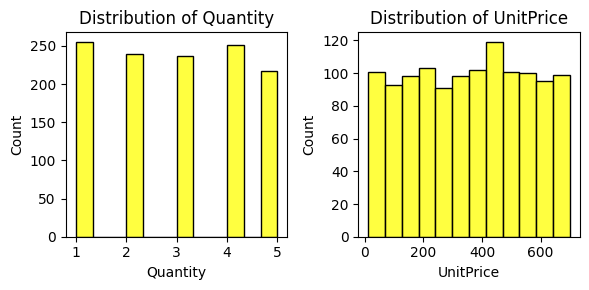

In [9]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.histplot(df['Quantity'],color='yellow',ax=axes[0])
axes[0].set_title('Distribution of Quantity')

sns.histplot(df['UnitPrice'],color='yellow',ax=axes[1])
axes[1].set_title('Distribution of UnitPrice')
plt.tight_layout()
plt.show()

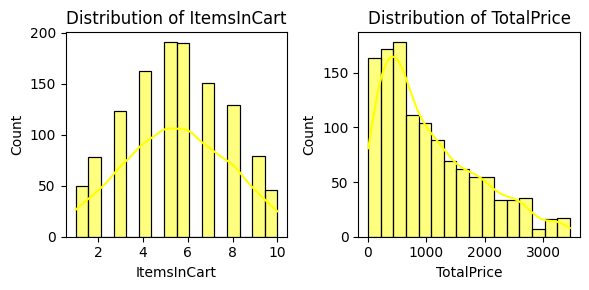

In [10]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.histplot(df['ItemsInCart'],color='yellow',ax=axes[0],kde=True)
axes[0].set_title('Distribution of ItemsInCart')

sns.histplot(df['TotalPrice'],color='yellow',ax=axes[1],kde=True)
axes[1].set_title('Distribution of TotalPrice')
plt.tight_layout()
plt.show()

In [11]:
# Obseravtion:

In [12]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].skew()

Quantity       0.027922
UnitPrice     -0.026512
ItemsInCart    0.000877
TotalPrice     0.891359
dtype: float64

In [13]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].kurtosis()

Quantity      -1.294596
UnitPrice     -1.191011
ItemsInCart   -0.708552
TotalPrice    -0.040415
dtype: float64

In [14]:
# 2ND Observation:
"""The skewness and kurtosis values indicate that Quantity, UnitPrice, and ItemsInCart are fairly balanced and do not contain significant extreme values. TotalPrice shows a slight right skew, meaning that while most orders have moderate values, a few higher-value transactions are present. Overall, the numerical columns appear well distributed without any major irregularities."""

'The skewness and kurtosis values indicate that Quantity, UnitPrice, and ItemsInCart are fairly balanced and do not contain significant extreme values. TotalPrice shows a slight right skew, meaning that while most orders have moderate values, a few higher-value transactions are present. Overall, the numerical columns appear well distributed without any major irregularities.'

In [15]:
# Check Outliers in Numerical Columns

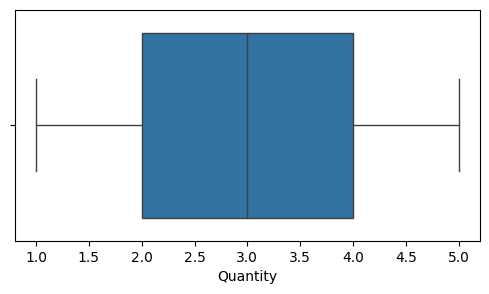

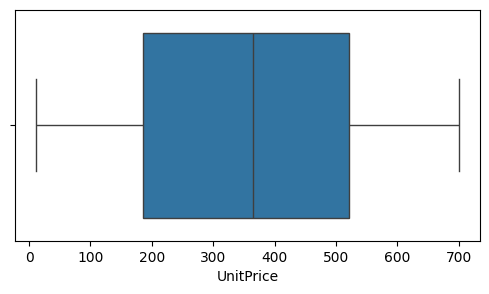

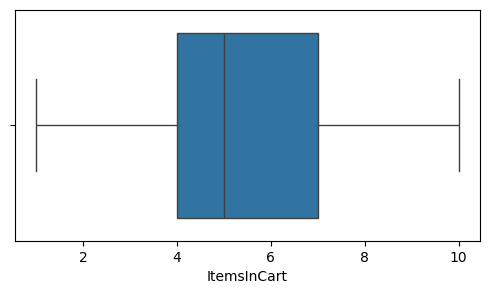

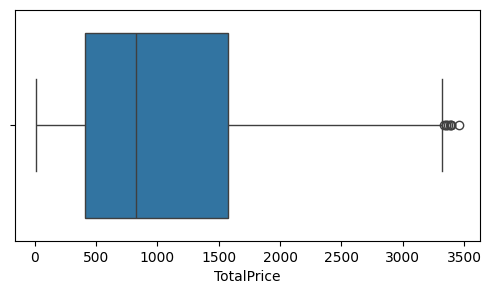

In [16]:
cols=['Quantity','UnitPrice','ItemsInCart','TotalPrice']
for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.show()

In [17]:
# Univariate Analysis of Categorical Columns

In [18]:
cols=['Product','PaymentMethod','OrderStatus','ReferralSource','CouponCode']
for col in cols:
    print(df[col].value_counts())
    print("--------")

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
--------
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64
--------
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
--------
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64
--------
CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64
--------


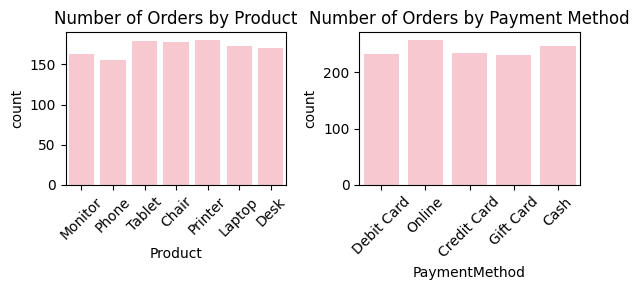

In [19]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.countplot(x=df['Product'],color='pink',ax=axes[0])
axes[0].set_title('Number of Orders by Product')
axes[0].tick_params(axis='x',rotation=45)

sns.countplot(x=df['PaymentMethod'],color='pink',ax=axes[1])
axes[1].set_title('Number of Orders by Payment Method')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

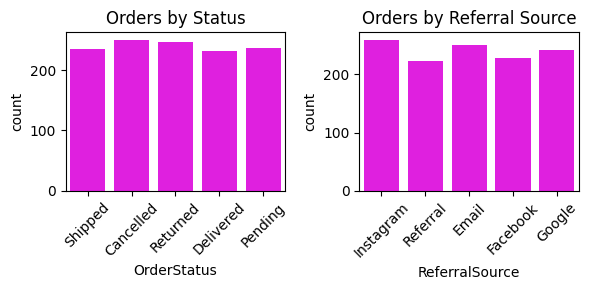

In [20]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.countplot(x=df['OrderStatus'],color='magenta',ax=axes[0])
axes[0].set_title('Orders by Status')
axes[0].tick_params(axis='x',rotation=45)

sns.countplot(x=df['ReferralSource'],color='magenta',ax=axes[1])
axes[1].set_title('Orders by Referral Source')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

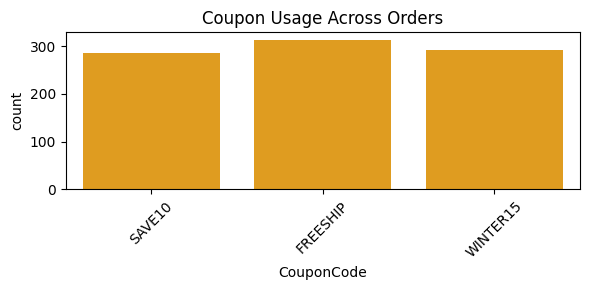

In [21]:
plt.figure(figsize=(6,3))
sns.countplot(x=df['CouponCode'],color='orange')
plt.title('Coupon Usage Across Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
product_revenue=df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(product_revenue)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


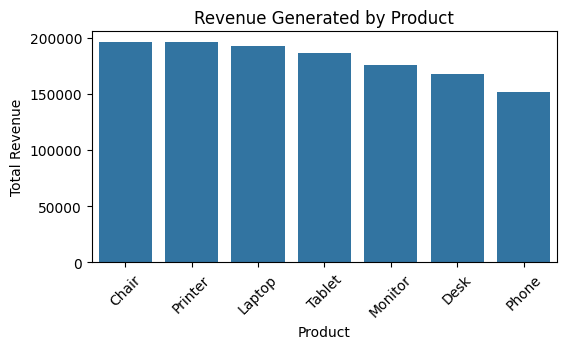

In [23]:
plt.figure(figsize=(6,3))
sns.barplot(x=product_revenue.index, y=product_revenue.values)
plt.title('Revenue Generated by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [24]:
product_quantity=df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print(product_quantity)

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64


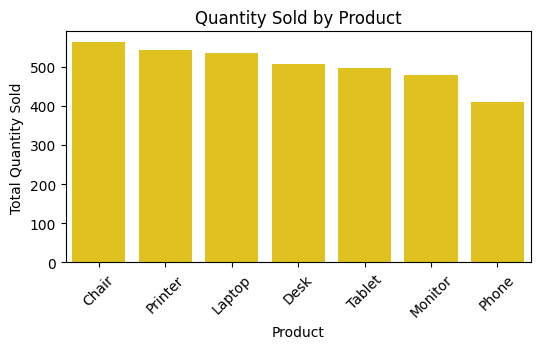

In [25]:
plt.figure(figsize=(6,3))
sns.barplot(x=product_quantity.index, y=product_quantity.values,color='gold')
plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()